In [2]:

%load_ext autoreload
%autoreload 2
    
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

#from functions.sc_pos.ballistic_backmap import run_backmapping


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\final.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\general.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\sig_c_sig_r.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\mag_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\qtn_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\par_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\sc_pot_gaps.pkl


17-Feb-26 08:52:55: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144 [sunpy.coordinates.ephemeris]
Wrote: {'maps': WindowsPath('C:/Users/nokni/work/MHDTurbPy/examples/figures/ballistic_backmap_demo/SOLO_int10/source_surface_maps.png'), 'timeseries': WindowsPath('C:/Users/nokni/work/MHDTurbPy/examples/figures/ballistic_backmap_demo/SOLO_int10/ballistic_backmap_timeseries.pkl')}
Columns available: ['Br', 'Vr', 'Np', 'dZpr', 'dZpt', 'dZpn', 'dZmr', 'dZmt', 'dZmn', 'dva_r', 'dva_t', 'dva_n', 'dv_r', 'dv_t', 'dv_n', 'Zpr', 'Zpt', 'Zpn', 'Zmr', 'Zmt', 'Zmn', 'va_r', 'va_t', 'va_n', 'v_r', 'v_t', 'v_n', 'beta', 'np', 'Tp', 'VB', 'd_i', 'Ma_inst', 'Ma', 'rho_i', 'Vsw', 'kin_norm', 'Ma_r', 'Va', 'sigma_c', 'sigma_r', 'Br_large', 'Vr_large', 'Np_large', 'sigma_c_large', 'Pram', 'lon_carr', 'lat', 'r_au', 'phi_src', 'lat_src', 'tau_days', 'vsw_fallback_used', 'Br_r2', 'Np_r2', 'marker_size']


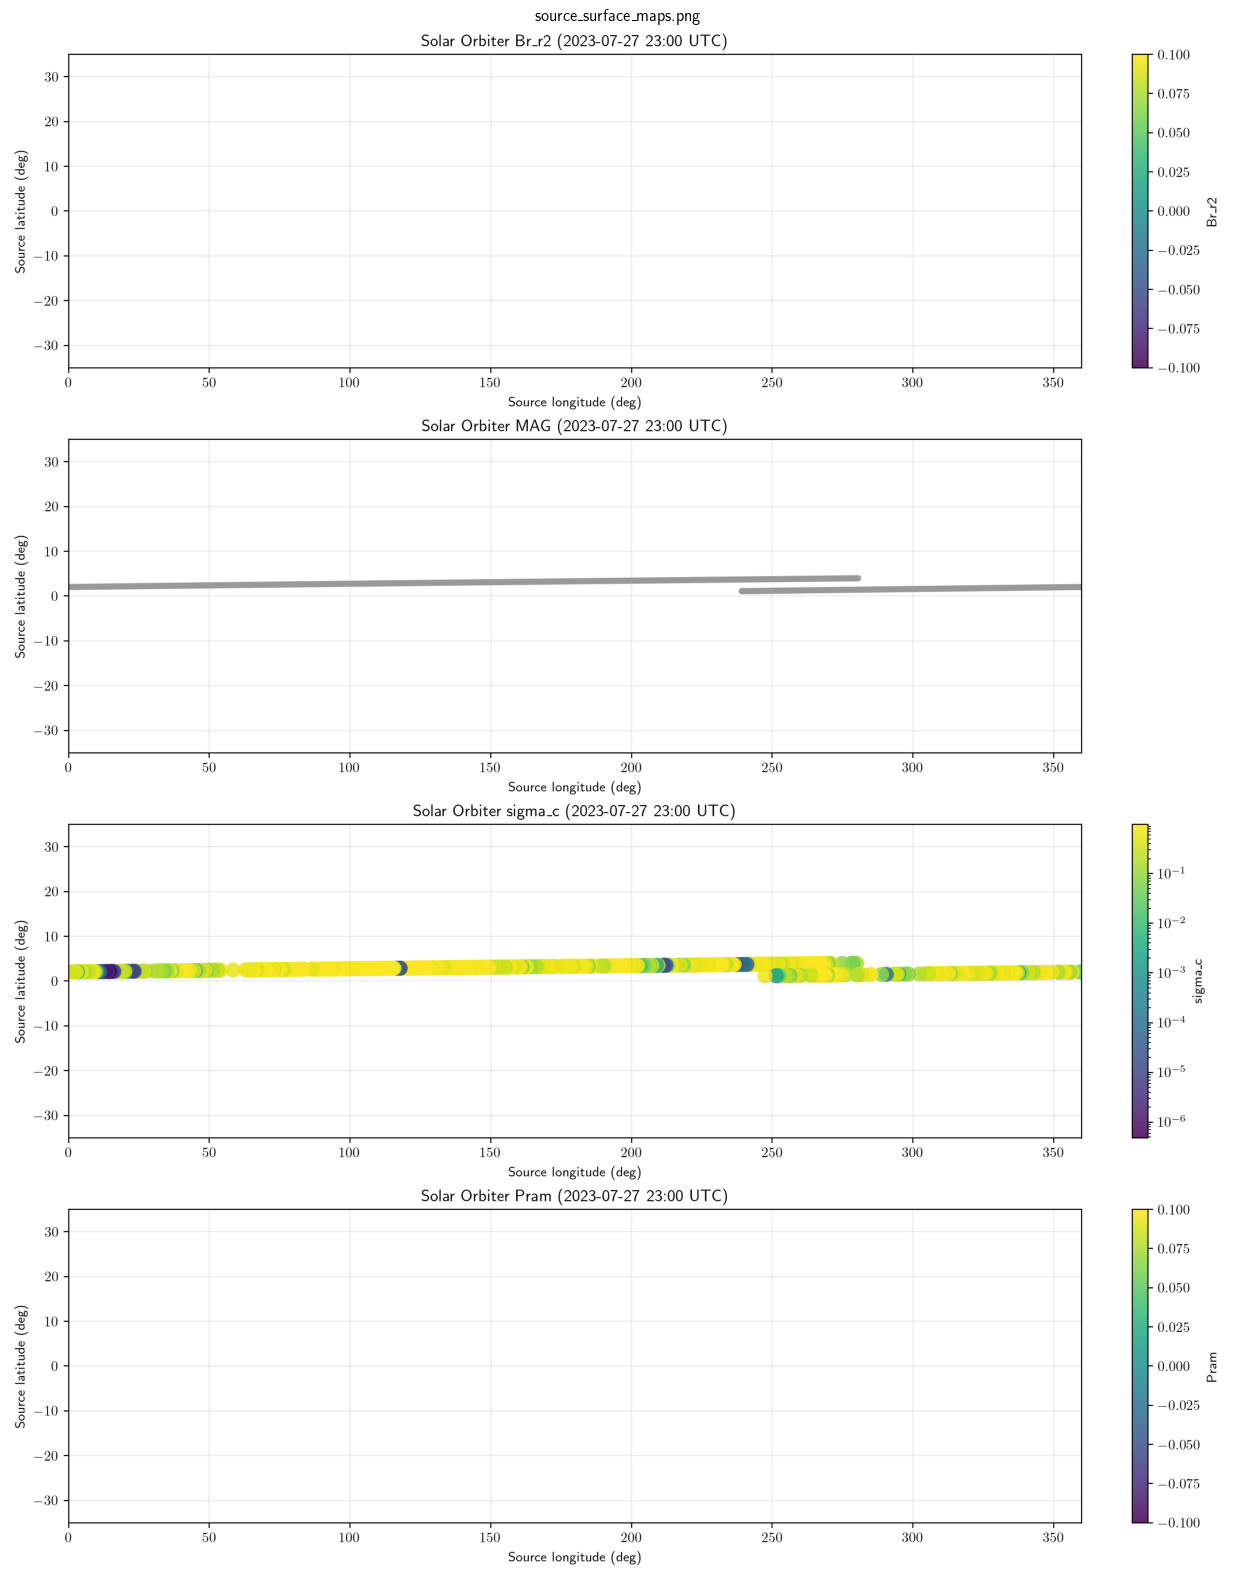

In [8]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------
# Project imports (match MHDTurbPy style)
# ---------------------------------------------------------------------
repo_root = Path.cwd().resolve()
if repo_root.name == "Notebooks_Examples":
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root / "functions"))

import general_functions as func
from sc_pos.ballistic_backmap import run_backmapping_interval

# ---------------------------------------------------------------------
# User inputs (interval-based, no dates)
# ---------------------------------------------------------------------
sc = "SOLO"
which_int = 10
load_path = repo_root / "examples" / "downloaded_intervals" / sc
outdir = repo_root / "examples" / "figures" / "ballistic_backmap_demo" / f"{sc}_int{which_int:02d}"

# What to plot on the source-surface map:
# - "polarity" is special: sign(Br_large) red/blue
# - anything else must be a column available after loading/joining:
#     core: Br, Vr, Np, Br_r2, Np_r2, Pram
#     from sig file: sigma_c, sigma_r, ... (and *_large if requested)
plot_vars = ["Br_r2","polarity", "sigma_c", "Pram"]

cfg = dict(
    cadence="60min",
    smooth="1h",
    cache_ephem=True,
    plot_vars=plot_vars,
    size_by="Pram",
    target       = sc,
    target_label = "Solar Orbiter",
)

result = run_backmapping_interval(
    root_dir=repo_root,
    sc=sc,
    which_int=which_int,
    outdir=outdir,
    **cfg,
)

data = result["data"]
files = result["files"]

print("Wrote:", files)
print("Columns available:", list(data.columns))

# ---------------------------------------------------------------------
# Display the multi-panel map
# ---------------------------------------------------------------------
img = plt.imread(files["maps"])
plt.figure(figsize=(22, 20))
plt.imshow(img)
plt.axis("off")
plt.title(Path(files["maps"]).name)
plt.show()

In [9]:
data

,Br,Vr,Np,dZpr,dZpt,dZpn,dZmr,dZmt,dZmn,dva_r,...,lon_carr,lat,r_au,phi_src,lat_src,tau_days,vsw_fallback_used,Br_r2,Np_r2,marker_size
datetime,,,,,,,,,,,,,,,,,,,,,
2023-06-28 00:00:00+00:00,-0.818671,371.251556,17.380783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,337.705271,3.972665,0.942788,280.532672,3.972665,4.030667,True,NaN,NaN,116.0
2023-06-28 01:00:00+00:00,1.013241,362.625000,18.657097,-15.324333,-2.980344,4.080898,7.263542,2.797300,3.305039,11.293938,...,337.145017,3.968928,0.942871,279.967361,3.968928,4.031024,True,NaN,NaN,116.0
2023-06-28 02:00:00+00:00,3.026992,347.732300,22.979427,-2.496814,3.129541,-2.613373,-6.557650,4.928745,1.045139,-2.030418,...,336.584758,3.965189,0.942953,279.402063,3.965189,4.031379,True,NaN,NaN,116.0
2023-06-28 03:00:00+00:00,2.674351,344.759491,41.928162,-3.776248,-0.867155,-4.722775,-2.765530,4.543048,-4.564451,0.505359,...,336.024493,3.961451,0.943034,278.836778,3.961451,4.031733,True,NaN,NaN,116.0
2023-06-28 04:00:00+00:00,2.986800,348.317078,40.780102,1.941760,-2.165451,-3.451470,0.545918,2.527367,-2.639666,-0.697921,...,335.464222,3.957712,0.943116,278.271506,3.957712,4.032086,True,NaN,NaN,116.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-27 19:00:00+00:00,4.971315,721.013733,1.801818,-0.196779,3.288790,-3.903446,15.562206,-2.064749,-30.204073,7.879493,...,296.894644,1.101786,0.924846,240.823690,1.101786,3.953001,True,NaN,NaN,116.0
2023-07-27 20:00:00+00:00,4.991725,708.670288,1.811327,2.087122,-2.456287,-0.359584,-2.622186,-5.578391,-1.039262,-2.354654,...,296.335460,1.097359,0.924712,240.272710,1.097359,3.952423,True,NaN,NaN,116.0
2023-07-27 21:00:00+00:00,4.861176,705.739075,1.391029,0.727927,0.214341,2.225355,3.919494,-3.910495,-1.301173,1.595783,...,295.776286,1.092931,0.924578,239.721759,1.092931,3.951843,True,NaN,NaN,116.0
